In [1]:
import os
from pathlib import Path
import torch

print("cwd:", os.getcwd())
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

print("src/config.py exists:", Path("src/config.py").exists())
print("files here:", list(Path(".").iterdir())[:20])

cwd: /Users/kacper/polish-hatespeech-audit
CUDA available: False
GPU: NO GPU
src/config.py exists: True
files here: [PosixPath('paper'), PosixPath('evaluation_plan.md'), PosixPath('requirements.txt'), PosixPath('trelbert_notebook.ipynb'), PosixPath('README.md'), PosixPath('results'), PosixPath('venv'), PosixPath('.git'), PosixPath('data'), PosixPath('notebooks'), PosixPath('src')]


In [7]:
!git clone https://github.com/pasinskik/polish-hatespeech-audit.git
%cd polish-hatespeech-audit

Cloning into 'polish-hatespeech-audit'...
remote: Enumerating objects: 88, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 88 (delta 18), reused 79 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (88/88), 1.37 MiB | 31.78 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/polish-hatespeech-audit/polish-hatespeech-audit


In [2]:
!pip install -q --upgrade pip
!pip install -q --upgrade transformers datasets accelerate scikit-learn pandas pyarrow scipy statsmodels huggingface_hub

In [6]:
%%writefile src/train_trelbert.py
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import torch
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

from config import ROOT, SEED, TRELBERT_MODEL_ID

DATASET_ID = "ptaszynski/PolishCyberbullyingDataset"
OUT_DIR = ROOT / "models" / "trelbert-cyberbullying-binary"

TEXT_COL = "TEXT"
LABEL_COL = "GENERAL TAG"

MAX_LENGTH = 128


def preprocess_text(text: str) -> str:
    text = str(text)
    text = text.replace("@anonymized_user", "@anonymized_account")
    return text


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision, recall, harmful_f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary",
        pos_label=1,
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "harmful_precision": precision,
        "harmful_recall": recall,
        "harmful_f1": harmful_f1,
    }


def class_balance(ds, name: str) -> dict:
    labels = np.array(ds["labels"])
    n0 = int((labels == 0).sum())
    n1 = int((labels == 1).sum())
    out = {
        "split": name,
        "n": int(len(labels)),
        "non_harmful_0": n0,
        "harmful_1": n1,
        "harmful_share": float(n1 / len(labels)),
    }
    print(out)
    return out


def main():
    set_seed(SEED)
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    print(f"Loading dataset: {DATASET_ID}")
    ds = load_dataset(DATASET_ID)
    print(ds)

    print("Train columns:", ds["train"].column_names)
    print("Test columns:", ds["test"].column_names)

    if TEXT_COL not in ds["train"].column_names:
        raise ValueError(f"Missing text column {TEXT_COL}. Available: {ds['train'].column_names}")
    if LABEL_COL not in ds["train"].column_names:
        raise ValueError(f"Missing label column {LABEL_COL}. Available: {ds['train'].column_names}")

    def prepare_example(example):
        return {
            "text": preprocess_text(example[TEXT_COL]),
            "labels": int(example[LABEL_COL]),
        }

    train_full = ds["train"].map(prepare_example)
    test_ds = ds["test"].map(prepare_example)

    labels = np.array(train_full["labels"])
    indices = np.arange(len(train_full))

    train_idx, val_idx = train_test_split(
        indices,
        test_size=0.1,
        random_state=SEED,
        stratify=labels,
    )

    train_ds = train_full.select(train_idx.tolist())
    val_ds = train_full.select(val_idx.tolist())

    balance = [
        class_balance(train_ds, "train"),
        class_balance(val_ds, "validation"),
        class_balance(test_ds, "test"),
    ]

    tokenizer = AutoTokenizer.from_pretrained(TRELBERT_MODEL_ID)

    def tokenize(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=MAX_LENGTH,
        )

    train_ds = train_ds.map(tokenize, batched=True)
    val_ds = val_ds.map(tokenize, batched=True)
    test_ds = test_ds.map(tokenize, batched=True)

    keep_cols = ["input_ids", "attention_mask", "labels"]
    train_ds.set_format("torch", columns=keep_cols)
    val_ds.set_format("torch", columns=keep_cols)
    test_ds.set_format("torch", columns=keep_cols)

    model = AutoModelForSequenceClassification.from_pretrained(
        TRELBERT_MODEL_ID,
        num_labels=2,
        id2label={0: "non-harmful", 1: "harmful"},
        label2id={"non-harmful": 0, "harmful": 1},
    )

    common_args = dict(
        output_dir=str(OUT_DIR),
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=4,
        weight_decay=0.01,
        warmup_ratio=0.1,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        save_total_limit=2,
        logging_steps=50,
        seed=SEED,
        fp16=torch.cuda.is_available(),
        report_to="none",
    )

    try:
        args = TrainingArguments(eval_strategy="epoch", **common_args)
    except TypeError:
        args = TrainingArguments(evaluation_strategy="epoch", **common_args)

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
    )

    trainer.train()

    print("\nValidation metrics:")
    val_metrics = trainer.evaluate(val_ds)
    print(val_metrics)

    print("\nOfficial test metrics:")
    test_metrics = trainer.evaluate(test_ds)
    print(test_metrics)

    OUT_DIR.mkdir(parents=True, exist_ok=True)
    trainer.save_model(str(OUT_DIR))
    tokenizer.save_pretrained(str(OUT_DIR))

    run_log = {
        "base_model": TRELBERT_MODEL_ID,
        "dataset": DATASET_ID,
        "text_col": TEXT_COL,
        "label_col": LABEL_COL,
        "max_length": MAX_LENGTH,
        "seed": SEED,
        "learning_rate": 2e-5,
        "batch_size_train": 16,
        "batch_size_eval": 32,
        "epochs": 4,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1,
        "class_balance": balance,
        "validation_metrics": val_metrics,
        "test_metrics": test_metrics,
        "checkpoint_path": str(OUT_DIR),
    }

    with open(OUT_DIR / "training_run.json", "w", encoding="utf-8") as f:
        json.dump(run_log, f, indent=2, ensure_ascii=False)

    print(f"\nSaved model to: {OUT_DIR}")


if __name__ == "__main__":
    main()

Overwriting src/train_trelbert.py


In [7]:
from pathlib import Path

p = Path("src/config.py")
txt = p.read_text()

line = 'TRELBERT_FINETUNED_MODEL_ID = str(ROOT / "models" / "trelbert-cyberbullying-binary")\n'

if "TRELBERT_FINETUNED_MODEL_ID" not in txt:
    txt += "\n" + line

p.write_text(txt)
print(p.read_text())

from pathlib import Path

ROOT = Path(__file__).resolve().parent.parent
DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"

HATECHECK_HF_ID = "Paul/hatecheck-polish"

PTASZYNSKI_MODEL_ID = "ptaszynski/bert-base-polish-cyberbullying"
TRELBERT_MODEL_ID = "deepsense-ai/trelbert"

BATCH_SIZE = 32
MAX_LENGTH = 256
SEED = 42

FEMININE_NAMES = ["Julia", "Maja", "Hanna", "Zofia", "Wiktoria"]
MASCULINE_NAMES = ["Jakub", "Antoni", "Szymon", "Jan", "Filip"]
NEUTRAL_PREFIX = "Osoba"

PREFIX_FORMAT = "{name}: {text}"

CYBERBULLYING_HF_ID = "ptaszynski/PolishCyberbullyingDataset"
TRELBERT_FINETUNED_MODEL_ID = str(ROOT / "models" / "trelbert-cyberbullying-binary")


In [8]:
from pathlib import Path

for file_name in ["src/baseline.py", "src/cf_inference.py"]:
    p = Path(file_name)
    txt = p.read_text()

    old_import = "from config import BATCH_SIZE, DATA_DIR, MAX_LENGTH, PTASZYNSKI_MODEL_ID, RESULTS_DIR, SEED"
    new_import = "from config import BATCH_SIZE, DATA_DIR, MAX_LENGTH, PTASZYNSKI_MODEL_ID, TRELBERT_FINETUNED_MODEL_ID, RESULTS_DIR, SEED"
    txt = txt.replace(old_import, new_import)

    old_models = '''MODELS = {
    "ptaszynski": dict(model_id=PTASZYNSKI_MODEL_ID, harmful_index=1),
}'''

    new_models = '''MODELS = {
    "ptaszynski": dict(model_id=PTASZYNSKI_MODEL_ID, harmful_index=1),
    "trelbert": dict(model_id=TRELBERT_FINETUNED_MODEL_ID, harmful_index=1),
}'''

    txt = txt.replace(old_models, new_models)

    p.write_text(txt)
    print(f"patched {file_name}")

patched src/baseline.py
patched src/cf_inference.py


In [11]:
from pathlib import Path

p = Path("src/train_trelbert.py")
txt = p.read_text()

old = """    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
    )
"""

new = """    # transformers compatibility:
    # older versions used `tokenizer=...`, newer versions use `processing_class=...`
    trainer_kwargs = dict(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
    )

    try:
        trainer = Trainer(
            **trainer_kwargs,
            processing_class=tokenizer,
        )
    except TypeError:
        trainer = Trainer(
            **trainer_kwargs,
            tokenizer=tokenizer,
        )
"""

if old not in txt:
    print("Exact block not found. Showing nearby Trainer block:")
    start = txt.find("trainer = Trainer(")
    print(txt[start:start+500])
else:
    txt = txt.replace(old, new)
    p.write_text(txt)
    print("Patched src/train_trelbert.py")

Patched src/train_trelbert.py


In [12]:
!python src/train_trelbert.py

Loading dataset: ptaszynski/PolishCyberbullyingDataset
DatasetDict({
    train: Dataset({
        features: ['TEXT', 'GENERAL TAG', 'SPECIFIC TAG', 'CATEGORIES', 'ANY PROFANITIES?'],
        num_rows: 10038
    })
    test: Dataset({
        features: ['TEXT', 'GENERAL TAG', 'SPECIFIC TAG', 'CATEGORIES', 'ANY PROFANITIES?'],
        num_rows: 1000
    })
})
Train columns: ['TEXT', 'GENERAL TAG', 'SPECIFIC TAG', 'CATEGORIES', 'ANY PROFANITIES?']
Test columns: ['TEXT', 'GENERAL TAG', 'SPECIFIC TAG', 'CATEGORIES', 'ANY PROFANITIES?']
{'split': 'train', 'n': 9034, 'non_harmful_0': 7611, 'harmful_1': 1423, 'harmful_share': 0.15751605047597964}
{'split': 'validation', 'n': 1004, 'non_harmful_0': 846, 'harmful_1': 158, 'harmful_share': 0.15737051792828685}
{'split': 'test', 'n': 1000, 'non_harmful_0': 811, 'harmful_1': 189, 'harmful_share': 0.189}
Loading weights: 100% 197/197 [00:00<00:00, 28429.60it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: deepsense-ai/trelbert
Key 

In [13]:
!ls -lh models/trelbert-cyberbullying-binary
!cat models/trelbert-cyberbullying-binary/training_run.json

total 479M
drwxr-xr-x 2 root root 4.0K Jun 30 17:47 checkpoint-1695
drwxr-xr-x 2 root root 4.0K Jun 30 17:48 checkpoint-2260
-rw-r--r-- 1 root root  947 Jun 30 17:48 config.json
-rw------- 1 root root 475M Jun 30 17:48 model.safetensors
-rw-r--r-- 1 root root  421 Jun 30 17:48 tokenizer_config.json
-rw-r--r-- 1 root root 3.6M Jun 30 17:48 tokenizer.json
-rw-r--r-- 1 root root 5.2K Jun 30 17:48 training_args.bin
-rw-r--r-- 1 root root 1.7K Jun 30 17:48 training_run.json
{
  "base_model": "deepsense-ai/trelbert",
  "dataset": "ptaszynski/PolishCyberbullyingDataset",
  "text_col": "TEXT",
  "label_col": "GENERAL TAG",
  "max_length": 128,
  "seed": 42,
  "learning_rate": 2e-05,
  "batch_size_train": 16,
  "batch_size_eval": 32,
  "epochs": 4,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "class_balance": [
    {
      "split": "train",
      "n": 9034,
      "non_harmful_0": 7611,
      "harmful_1": 1423,
      "harmful_share": 0.15751605047597964
    },
    {
      "split": "validatio

In [14]:
!python src/load_dataset.py
!python src/baseline.py --model trelbert

Ładuję Paul/hatecheck-polish...
README.md: 100% 3.49k/3.49k [00:00<00:00, 1.16MB/s]
test.csv: 100% 968k/968k [00:00<00:00, 61.8MB/s]
Generating test split: 100% 3815/3815 [00:00<00:00, 49349.32 examples/s]
Splity: ['test']
  test: n=3815, kolumny=['mhc_case_id', 'functionality', 'test_case', 'label_gold', 'target_ident', 'ref_case_id', 'ref_templ_id', 'templ_id', 'case_templ', 'gender_male', 'gender_female', 'label_annotated', 'label_annotated_maj', 'disagreement_in_case', 'disagreement_in_template']

Przykładowe wiersze:
  mhc_case_id      functionality                      test_case label_gold     target_ident  ref_case_id  ref_templ_id  templ_id             case_templ gender_male gender_female                    label_annotated label_annotated_maj  disagreement_in_case  disagreement_in_template
0    polish-1  derog_neg_emote_h              Nienawidzę gejów.    hateful       gay people          NaN           NaN         1  Nienawidzę [IDENT_P].         NaN           NaN  ['hateful', 

In [15]:
!python src/counterfactual_dataset.py
!python src/cf_inference.py --model trelbert

Czytam: /content/polish-hatespeech-audit/data/hatecheck_pl.parquet
Przykładów bazowych: 3815

Long format: 45780 wierszy = 3815 × 12

Rozkład prefix_class:
prefix_class
feminine     19075
masculine    19075
original      3815
neutral       3815
Name: count, dtype: int64

Rozkład wariantów (powinno być po 3815 każdy):
variant
feminine_Hanna       3815
feminine_Julia       3815
feminine_Maja        3815
feminine_Wiktoria    3815
feminine_Zofia       3815
masculine_Antoni     3815
masculine_Filip      3815
masculine_Jakub      3815
masculine_Jan        3815
masculine_Szymon     3815
neutral              3815
original             3815

Zapisano: /content/polish-hatespeech-audit/data/counterfactual_dataset.parquet (0.44 MB)

Przykład pełnego rekordu (polish-2656, wszystkie 12 wariantów):
          variant prefix_class prefix_name                                                                        text
         original     original         NaN           Twoja oczywista pogarda dla kobiet

In [8]:
!python src/cf_statistical_analysis.py --model trelbert

Cases: 3815, variants in p_wide: 14

Zapisano: /content/polish-hatespeech-audit/polish-hatespeech-audit/results/cf_trelbert_statistical_tests.parquet  (222 testów)

=== GLOBAL: 6 par porównań ===
           pair    n  delta_mean  delta_ci_low  delta_ci_high  flip_rate  wilcoxon_p  mcnemar_p  cohens_h
    fem_vs_orig 3815     -0.0237       -0.0308        -0.0171     0.0920      0.0000     0.0000   -0.0602
   masc_vs_orig 3815     -0.0029       -0.0100         0.0032     0.0855      0.0000     0.0308   -0.0212
neutral_vs_orig 3815     -0.0383       -0.0465        -0.0302     0.1211      0.8583     0.0000   -0.0962
 fem_vs_neutral 3815      0.0146        0.0098         0.0194     0.0700      0.0000     0.0001    0.0360
masc_vs_neutral 3815      0.0353        0.0299         0.0408     0.0818      0.0000     0.0000    0.0750
    fem_vs_masc 3815     -0.0207       -0.0231        -0.0185     0.0291      0.0000     0.0000   -0.0389

=== Per-functionality summary (pair=fem_vs_masc, significant 

In [3]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(".").resolve()
RESULTS_DIR = ROOT / "results"
OUT_DIR = ROOT / "paper" / "generated_trelbert_analysis"
FIG_DIR = ROOT / "paper" / "figs"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

required = [
    "baseline_ptaszynski_run.json",
    "baseline_trelbert_run.json",
    "baseline_ptaszynski_per_functionality.parquet",
    "baseline_trelbert_per_functionality.parquet",
    "baseline_ptaszynski_per_target_ident.parquet",
    "baseline_trelbert_per_target_ident.parquet",
    "baseline_ptaszynski_predictions.parquet",
    "baseline_trelbert_predictions.parquet",
    "cf_ptaszynski_statistical_tests.parquet",
    "cf_trelbert_statistical_tests.parquet",
    "cf_ptaszynski_predictions.parquet",
    "cf_trelbert_predictions.parquet",
]

missing = [f for f in required if not (RESULTS_DIR / f).exists()]

print("ROOT:", ROOT)
print("RESULTS_DIR:", RESULTS_DIR)
print("Missing files:", missing if missing else "none")

for f in sorted(RESULTS_DIR.glob("*trelbert*")):
    print(f.name, round(f.stat().st_size / 1024 / 1024, 2), "MB")

ROOT: /Users/kacper/polish-hatespeech-audit
RESULTS_DIR: /Users/kacper/polish-hatespeech-audit/results
Missing files: none
baseline_trelbert_per_functionality.parquet 0.01 MB
baseline_trelbert_per_target_ident.parquet 0.01 MB
baseline_trelbert_predictions.parquet 0.05 MB
baseline_trelbert_run.json 0.0 MB
cf_trelbert_predictions.parquet 0.29 MB
cf_trelbert_run.json 0.0 MB
cf_trelbert_statistical_tests.parquet 0.03 MB


In [4]:
def load_json(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def pct(x, digits=1):
    if pd.isna(x):
        return "—"
    return f"{100 * x:.{digits}f}%"


def num(x, digits=3):
    if pd.isna(x):
        return "—"
    return f"{x:.{digits}f}"


def pp(x, digits=1):
    if pd.isna(x):
        return "—"
    return f"{100 * x:+.{digits}f} pp"


def clean_target(x):
    if pd.isna(x) or x == "__none__":
        return "no target"
    return x


def read_table(path: Path) -> pd.DataFrame:
    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    if path.suffix == ".csv":
        return pd.read_csv(path)
    raise ValueError(path)

In [5]:
m1_run = load_json(RESULTS_DIR / "baseline_ptaszynski_run.json")
m2_run = load_json(RESULTS_DIR / "baseline_trelbert_run.json")

m1_func = pd.read_parquet(RESULTS_DIR / "baseline_ptaszynski_per_functionality.parquet")
m2_func = pd.read_parquet(RESULTS_DIR / "baseline_trelbert_per_functionality.parquet")

m1_target = pd.read_parquet(RESULTS_DIR / "baseline_ptaszynski_per_target_ident.parquet")
m2_target = pd.read_parquet(RESULTS_DIR / "baseline_trelbert_per_target_ident.parquet")

m1_pred = pd.read_parquet(RESULTS_DIR / "baseline_ptaszynski_predictions.parquet")
m2_pred = pd.read_parquet(RESULTS_DIR / "baseline_trelbert_predictions.parquet")

m1_cf_stats = pd.read_parquet(RESULTS_DIR / "cf_ptaszynski_statistical_tests.parquet")
m2_cf_stats = pd.read_parquet(RESULTS_DIR / "cf_trelbert_statistical_tests.parquet")

m1_cf_pred = pd.read_parquet(RESULTS_DIR / "cf_ptaszynski_predictions.parquet")
m2_cf_pred = pd.read_parquet(RESULTS_DIR / "cf_trelbert_predictions.parquet")

print("M1 baseline rows:", len(m1_pred))
print("M2 baseline rows:", len(m2_pred))
print("M1 CF rows:", len(m1_cf_pred))
print("M2 CF rows:", len(m2_cf_pred))

print("\nM2 baseline run:")
m2_run

M1 baseline rows: 3815
M2 baseline rows: 3815
M1 CF rows: 45780
M2 CF rows: 45780

M2 baseline run:


{'model_key': 'trelbert',
 'model_id': '/content/polish-hatespeech-audit/models/trelbert-cyberbullying-binary',
 'model_revision': None,
 'harmful_index': 1,
 'threshold': 0.5,
 'batch_size': 32,
 'max_length': 256,
 'seed': 42,
 'device': 'cuda',
 'torch_version': '2.11.0+cu128',
 'transformers_version': '5.12.1',
 'dataset_path': '/content/polish-hatespeech-audit/data/hatecheck_pl.parquet',
 'n_examples': 3815,
 'overall_metrics': {'n': 3815,
  'accuracy': 0.5549148099606815,
  'macro_f1': 0.5473558567094696,
  'fpr': 0.2858399296394019,
  'fnr': 0.5126960418222554,
  'n_pos': 2678,
  'n_neg': 1137,
  'roc_auc': 0.658599697985409}}

In [6]:
def overall_from_run(run: dict, model_label: str) -> dict:
    m = run["overall_metrics"]
    return {
        "model": model_label,
        "n": m.get("n"),
        "accuracy": m.get("accuracy"),
        "macro_f1": m.get("macro_f1"),
        "roc_auc": m.get("roc_auc"),
        "fpr": m.get("fpr"),
        "fnr": m.get("fnr"),
        "n_pos": m.get("n_pos"),
        "n_neg": m.get("n_neg"),
    }


overall = pd.DataFrame([
    overall_from_run(m1_run, "M1: ptaszynski"),
    overall_from_run(m2_run, "M2: TrelBERT"),
])

overall["accuracy_fmt"] = overall["accuracy"].map(lambda x: num(x, 3))
overall["macro_f1_fmt"] = overall["macro_f1"].map(lambda x: num(x, 3))
overall["roc_auc_fmt"] = overall["roc_auc"].map(lambda x: num(x, 3))
overall["fpr_fmt"] = overall["fpr"].map(lambda x: num(x, 3))
overall["fnr_fmt"] = overall["fnr"].map(lambda x: num(x, 3))

display(overall)

overall_out = overall[["model", "n", "n_pos", "n_neg", "accuracy", "macro_f1", "roc_auc", "fpr", "fnr"]]
overall_out.to_csv(OUT_DIR / "baseline_overall_m1_m2.csv", index=False)

print("Saved:", OUT_DIR / "baseline_overall_m1_m2.csv")

,model,n,accuracy,macro_f1,roc_auc,fpr,fnr,n_pos,n_neg,accuracy_fmt,macro_f1_fmt,roc_auc_fmt,fpr_fmt,fnr_fmt
0,M1: ptaszynski,3815,0.525557,0.519986,0.625057,0.299033,0.548917,2678,1137,0.526,0.520,0.625,0.299,0.549
1,M2: TrelBERT,3815,0.554915,0.547356,0.658600,0.285840,0.512696,2678,1137,0.555,0.547,0.659,0.286,0.513


Saved: /Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/baseline_overall_m1_m2.csv


In [7]:
m1 = overall.set_index("model").loc["M1: ptaszynski"]
m2 = overall.set_index("model").loc["M2: TrelBERT"]

delta_acc = m2["accuracy"] - m1["accuracy"]
delta_f1 = m2["macro_f1"] - m1["macro_f1"]
delta_auc = m2["roc_auc"] - m1["roc_auc"]
delta_fnr = m2["fnr"] - m1["fnr"]
delta_fpr = m2["fpr"] - m1["fpr"]

paragraph = f"""
On the full Polish HateCheck, M2 reaches accuracy {m2['accuracy']:.3f}, macro F1 {m2['macro_f1']:.3f}, and ROC-AUC {m2['roc_auc']:.3f}.
Compared with M1, this is a change of {delta_acc:+.3f} in accuracy, {delta_f1:+.3f} in macro F1, and {delta_auc:+.3f} in ROC-AUC.
The false-positive rate is {m2['fpr']:.3f}, while the false-negative rate is {m2['fnr']:.3f}.
Relative to M1, this changes FPR by {delta_fpr:+.3f} and FNR by {delta_fnr:+.3f}.
This means that fine-tuning TrelBERT on the Polish cyberbullying corpus {'improves' if delta_f1 > 0 else 'does not improve'} aggregate performance on the diagnostic HateCheck benchmark.
""".strip()

print(paragraph)

with open(OUT_DIR / "paragraph_baseline_m2.txt", "w", encoding="utf-8") as f:
    f.write(paragraph)

print("\nSaved:", OUT_DIR / "paragraph_baseline_m2.txt")

On the full Polish HateCheck, M2 reaches accuracy 0.555, macro F1 0.547, and ROC-AUC 0.659.
Compared with M1, this is a change of +0.029 in accuracy, +0.027 in macro F1, and +0.034 in ROC-AUC.
The false-positive rate is 0.286, while the false-negative rate is 0.513.
Relative to M1, this changes FPR by -0.013 and FNR by -0.036.
This means that fine-tuning TrelBERT on the Polish cyberbullying corpus improves aggregate performance on the diagnostic HateCheck benchmark.

Saved: /Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/paragraph_baseline_m2.txt


In [8]:
m2_func_sorted = m2_func.sort_values("accuracy", ascending=True).copy()

m2_worst5 = m2_func_sorted.head(5)
m2_best3 = m2_func_sorted.tail(3).sort_values("accuracy", ascending=False)

m2_func_summary = pd.concat([
    m2_worst5.assign(group="Five worst"),
    m2_best3.assign(group="Three best"),
])

cols = ["group", "functionality", "n", "n_pos", "n_neg", "accuracy", "macro_f1", "fpr", "fnr", "roc_auc"]
display(m2_func_summary[cols])

m2_func_summary[cols].to_csv(OUT_DIR / "m2_functionality_worst_best.csv", index=False)
print("Saved:", OUT_DIR / "m2_functionality_worst_best.csv")

,group,functionality,n,n_pos,n_neg,accuracy,macro_f1,fpr,fnr,roc_auc
3,Five worst,derog_impl_h,140,140,0,0.278571,0.217877,NaN,0.721429,NaN
5,Five worst,derog_neg_emote_h,140,140,0,0.300000,0.230769,NaN,0.700000,NaN
9,Five worst,negate_pos_h,140,140,0,0.307143,0.234973,NaN,0.692857,NaN
11,Five worst,phrase_question_h,140,140,0,0.314286,0.239130,NaN,0.685714,NaN
26,Five worst,threat_norm_h,140,140,0,0.392857,0.282051,NaN,0.607143,NaN
24,Three best,target_obj_nh,65,0,65,0.923077,0.480000,0.076923,NaN,NaN
6,Three best,ident_neutral_nh,140,0,140,0.892857,0.471698,0.107143,NaN,NaN
8,Three best,negate_neg_nh,140,0,140,0.871429,0.465649,0.128571,NaN,NaN


Saved: /Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/m2_functionality_worst_best.csv


In [9]:
func_cmp = (
    m1_func[["functionality", "n", "accuracy", "macro_f1", "fpr", "fnr", "roc_auc"]]
    .rename(columns={
        "accuracy": "m1_accuracy",
        "macro_f1": "m1_macro_f1",
        "fpr": "m1_fpr",
        "fnr": "m1_fnr",
        "roc_auc": "m1_roc_auc",
    })
    .merge(
        m2_func[["functionality", "accuracy", "macro_f1", "fpr", "fnr", "roc_auc"]]
        .rename(columns={
            "accuracy": "m2_accuracy",
            "macro_f1": "m2_macro_f1",
            "fpr": "m2_fpr",
            "fnr": "m2_fnr",
            "roc_auc": "m2_roc_auc",
        }),
        on="functionality",
        how="inner",
    )
)

func_cmp["delta_accuracy"] = func_cmp["m2_accuracy"] - func_cmp["m1_accuracy"]
func_cmp["delta_macro_f1"] = func_cmp["m2_macro_f1"] - func_cmp["m1_macro_f1"]
func_cmp["delta_fnr"] = func_cmp["m2_fnr"] - func_cmp["m1_fnr"]
func_cmp["delta_fpr"] = func_cmp["m2_fpr"] - func_cmp["m1_fpr"]

func_cmp_sorted = func_cmp.sort_values("delta_accuracy", ascending=False)

print("Largest M2 gains over M1:")
display(func_cmp_sorted.head(10))

print("Largest M2 drops vs M1:")
display(func_cmp_sorted.tail(10).sort_values("delta_accuracy"))

func_cmp.to_csv(OUT_DIR / "functionality_m1_m2_comparison.csv", index=False)
print("Saved:", OUT_DIR / "functionality_m1_m2_comparison.csv")

Largest M2 gains over M1:


,functionality,n,m1_accuracy,m1_macro_f1,m1_fpr,m1_fnr,m1_roc_auc,m2_accuracy,m2_macro_f1,m2_fpr,m2_fnr,m2_roc_auc,delta_accuracy,delta_macro_f1,delta_fnr,delta_fpr
20,spell_space_add_h,176,0.142045,0.124378,NaN,0.857955,NaN,0.420455,0.296000,NaN,0.579545,NaN,0.278409,0.171622,-0.278409,NaN
19,spell_leet_h,176,0.357955,0.263598,NaN,0.642045,NaN,0.568182,0.362319,NaN,0.431818,NaN,0.210227,0.098721,-0.210227,NaN
17,spell_char_del_h,140,0.435714,0.303483,NaN,0.564286,NaN,0.592857,0.372197,NaN,0.407143,NaN,0.157143,0.068715,-0.157143,NaN
1,counter_ref_nh,176,0.397727,0.284553,0.602273,NaN,NaN,0.551136,0.355311,0.448864,NaN,NaN,0.153409,0.070759,NaN,-0.153409
25,threat_dir_h,140,0.292857,0.226519,NaN,0.707143,NaN,0.435714,0.303483,NaN,0.564286,NaN,0.142857,0.076963,-0.142857,NaN
18,spell_char_swap_h,140,0.364286,0.267016,NaN,0.635714,NaN,0.478571,0.323671,NaN,0.521429,NaN,0.114286,0.056656,-0.114286,NaN
16,slur_h,190,0.584211,0.368771,NaN,0.415789,NaN,0.689474,0.408100,NaN,0.310526,NaN,0.105263,0.039329,-0.105263,NaN
10,phrase_opinion_h,140,0.342857,0.255319,NaN,0.657143,NaN,0.435714,0.303483,NaN,0.564286,NaN,0.092857,0.048163,-0.092857,NaN
21,spell_space_del_h,176,0.448864,0.309804,NaN,0.551136,NaN,0.539773,0.350554,NaN,0.460227,NaN,0.090909,0.040750,-0.090909,NaN
8,negate_neg_nh,140,0.785714,0.440000,0.214286,NaN,NaN,0.871429,0.465649,0.128571,NaN,NaN,0.085714,0.025649,NaN,-0.085714


Largest M2 drops vs M1:


,functionality,n,m1_accuracy,m1_macro_f1,m1_fpr,m1_fnr,m1_roc_auc,m2_accuracy,m2_macro_f1,m2_fpr,m2_fnr,m2_roc_auc,delta_accuracy,delta_macro_f1,delta_fnr,delta_fpr
4,derog_neg_attrib_h,140,0.778571,0.437751,NaN,0.221429,NaN,0.457143,0.313725,NaN,0.542857,NaN,-0.321429,-0.124026,0.321429,NaN
2,derog_dehum_h,140,0.778571,0.437751,NaN,0.221429,NaN,0.578571,0.366516,NaN,0.421429,NaN,-0.200000,-0.071235,0.200000,NaN
13,profanity_nh,100,0.680000,0.404762,0.320000,NaN,NaN,0.550000,0.354839,0.450000,NaN,NaN,-0.130000,-0.049923,NaN,0.130000
26,threat_norm_h,140,0.507143,0.336493,NaN,0.492857,NaN,0.392857,0.282051,NaN,0.607143,NaN,-0.114286,-0.054442,0.114286,NaN
11,phrase_question_h,140,0.385714,0.278351,NaN,0.614286,NaN,0.314286,0.239130,NaN,0.685714,NaN,-0.071429,-0.039220,0.071429,NaN
6,ident_neutral_nh,140,0.964286,0.490909,0.035714,NaN,NaN,0.892857,0.471698,0.107143,NaN,NaN,-0.071429,-0.019211,NaN,0.071429
3,derog_impl_h,140,0.342857,0.255319,NaN,0.657143,NaN,0.278571,0.217877,NaN,0.721429,NaN,-0.064286,-0.037442,0.064286,NaN
22,target_group_nh,65,0.676923,0.403670,0.323077,NaN,NaN,0.630769,0.386792,0.369231,NaN,NaN,-0.046154,-0.016877,NaN,0.046154
23,target_indiv_nh,65,0.615385,0.380952,0.384615,NaN,NaN,0.584615,0.368932,0.415385,NaN,NaN,-0.030769,-0.012020,NaN,0.030769
7,ident_pos_nh,210,0.761905,0.432432,0.238095,NaN,NaN,0.733333,0.423077,0.266667,NaN,NaN,-0.028571,-0.009356,NaN,0.028571


Saved: /Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/functionality_m1_m2_comparison.csv


In [10]:
worst = m2_worst5.copy()
best = m2_best3.copy()

gain_top = func_cmp.sort_values("delta_accuracy", ascending=False).head(3)
loss_top = func_cmp.sort_values("delta_accuracy", ascending=True).head(3)

worst_txt = ", ".join(
    f"{r.functionality} ({r.accuracy:.2f})"
    for r in worst.itertuples()
)

best_txt = ", ".join(
    f"{r.functionality} ({r.accuracy:.2f})"
    for r in best.itertuples()
)

gain_txt = ", ".join(
    f"{r.functionality} ({r.delta_accuracy:+.2f})"
    for r in gain_top.itertuples()
)

loss_txt = ", ".join(
    f"{r.functionality} ({r.delta_accuracy:+.2f})"
    for r in loss_top.itertuples()
)

paragraph_func = f"""
The per-functionality breakdown shows that M2's weakest categories are {worst_txt}.
Its strongest categories are {best_txt}.
Compared with M1, the largest M2 gains are observed in {gain_txt}, while the largest drops are observed in {loss_txt}.
This indicates that fine-tuning TrelBERT changes not only aggregate performance but also the model's failure profile across HateCheck functionalities.
""".strip()

print(paragraph_func)

with open(OUT_DIR / "paragraph_functionality_m2.txt", "w", encoding="utf-8") as f:
    f.write(paragraph_func)

print("\nSaved:", OUT_DIR / "paragraph_functionality_m2.txt")

The per-functionality breakdown shows that M2's weakest categories are derog_impl_h (0.28), derog_neg_emote_h (0.30), negate_pos_h (0.31), phrase_question_h (0.31), threat_norm_h (0.39).
Its strongest categories are target_obj_nh (0.92), ident_neutral_nh (0.89), negate_neg_nh (0.87).
Compared with M1, the largest M2 gains are observed in spell_space_add_h (+0.28), spell_leet_h (+0.21), spell_char_del_h (+0.16), while the largest drops are observed in derog_neg_attrib_h (-0.32), derog_dehum_h (-0.20), profanity_nh (-0.13).
This indicates that fine-tuning TrelBERT changes not only aggregate performance but also the model's failure profile across HateCheck functionalities.

Saved: /Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/paragraph_functionality_m2.txt


In [11]:
m2_target_clean = m2_target.copy()
m2_target_clean["target_ident"] = m2_target_clean["target_ident"].map(clean_target)
m2_target_clean = m2_target_clean.sort_values("accuracy")

display(m2_target_clean[["target_ident", "n", "accuracy", "macro_f1", "fpr", "fnr", "roc_auc"]])

m2_target_clean.to_csv(OUT_DIR / "m2_per_target_ident.csv", index=False)
print("Saved:", OUT_DIR / "m2_per_target_ident.csv")

,target_ident,n,accuracy,macro_f1,fpr,fnr,roc_auc
4,immigrants,458,0.451965,0.448365,0.227273,0.649425,0.652874
6,trans people,510,0.470588,0.469773,0.098361,0.664948,0.705150
7,women,510,0.498039,0.492348,0.180328,0.603093,0.685799
1,disabled people,510,0.500000,0.494541,0.172131,0.603093,0.674962
0,asian people,510,0.586275,0.560724,0.278689,0.456186,0.688081
5,jewish people,510,0.603922,0.566414,0.352459,0.409794,0.675987
8,no target,295,0.657627,0.396728,0.342373,NaN,NaN
2,gay people,510,0.701961,0.609660,0.549180,0.219072,0.659361
3,immigrant,2,1.000000,1.000000,NaN,0.000000,NaN


Saved: /Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/m2_per_target_ident.csv


In [12]:
m1_target_cmp = m1_target.copy()
m2_target_cmp = m2_target.copy()

m1_target_cmp["target_ident"] = m1_target_cmp["target_ident"].map(clean_target)
m2_target_cmp["target_ident"] = m2_target_cmp["target_ident"].map(clean_target)

target_cmp = (
    m1_target_cmp[["target_ident", "n", "accuracy", "macro_f1", "fpr", "fnr", "roc_auc"]]
    .rename(columns={
        "accuracy": "m1_accuracy",
        "macro_f1": "m1_macro_f1",
        "fpr": "m1_fpr",
        "fnr": "m1_fnr",
        "roc_auc": "m1_roc_auc",
    })
    .merge(
        m2_target_cmp[["target_ident", "accuracy", "macro_f1", "fpr", "fnr", "roc_auc"]]
        .rename(columns={
            "accuracy": "m2_accuracy",
            "macro_f1": "m2_macro_f1",
            "fpr": "m2_fpr",
            "fnr": "m2_fnr",
            "roc_auc": "m2_roc_auc",
        }),
        on="target_ident",
        how="inner",
    )
)

target_cmp["delta_accuracy"] = target_cmp["m2_accuracy"] - target_cmp["m1_accuracy"]
target_cmp["delta_macro_f1"] = target_cmp["m2_macro_f1"] - target_cmp["m1_macro_f1"]
target_cmp["delta_fpr"] = target_cmp["m2_fpr"] - target_cmp["m1_fpr"]
target_cmp["delta_fnr"] = target_cmp["m2_fnr"] - target_cmp["m1_fnr"]

display(target_cmp.sort_values("m2_accuracy"))

target_cmp.to_csv(OUT_DIR / "target_ident_m1_m2_comparison.csv", index=False)
print("Saved:", OUT_DIR / "target_ident_m1_m2_comparison.csv")

,target_ident,n,m1_accuracy,m1_macro_f1,m1_fpr,m1_fnr,m1_roc_auc,m2_accuracy,m2_macro_f1,m2_fpr,m2_fnr,m2_roc_auc,delta_accuracy,delta_macro_f1,delta_fpr,delta_fnr
4,immigrants,458,0.578603,0.549183,0.327273,0.451149,0.660005,0.451965,0.448365,0.227273,0.649425,0.652874,-0.126638,-0.100818,-0.100000,0.198276
6,trans people,510,0.415686,0.415650,0.114754,0.731959,0.647604,0.470588,0.469773,0.098361,0.664948,0.705150,0.054902,0.054122,-0.016393,-0.067010
7,women,510,0.439216,0.433773,0.286885,0.646907,0.601403,0.498039,0.492348,0.180328,0.603093,0.685799,0.058824,0.058575,-0.106557,-0.043814
1,disabled people,510,0.517647,0.495001,0.360656,0.520619,0.617606,0.500000,0.494541,0.172131,0.603093,0.674962,-0.017647,-0.000460,-0.188525,0.082474
0,asian people,510,0.533333,0.511423,0.327869,0.510309,0.643295,0.586275,0.560724,0.278689,0.456186,0.688081,0.052941,0.049300,-0.049180,-0.054124
5,jewish people,510,0.480392,0.473819,0.229508,0.610825,0.655738,0.603922,0.566414,0.352459,0.409794,0.675987,0.123529,0.092595,0.122951,-0.201031
8,no target,295,0.718644,0.418146,0.281356,NaN,NaN,0.657627,0.396728,0.342373,NaN,NaN,-0.061017,-0.021418,0.061017,NaN
2,gay people,510,0.607843,0.547680,0.491803,0.360825,0.616170,0.701961,0.609660,0.549180,0.219072,0.659361,0.094118,0.061980,0.057377,-0.141753
3,immigrant,2,0.500000,0.333333,NaN,0.500000,NaN,1.000000,1.000000,NaN,0.000000,NaN,0.500000,0.666667,NaN,-0.500000


Saved: /Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/target_ident_m1_m2_comparison.csv


In [13]:
m2_global = m2_cf_stats[m2_cf_stats["slice_type"] == "global"].copy()

pair_order = [
    "fem_vs_orig",
    "masc_vs_orig",
    "neutral_vs_orig",
    "fem_vs_neutral",
    "masc_vs_neutral",
    "fem_vs_masc",
]

m2_global["pair"] = pd.Categorical(m2_global["pair"], categories=pair_order, ordered=True)
m2_global = m2_global.sort_values("pair")

display(m2_global[
    [
        "pair",
        "n",
        "delta_mean",
        "delta_ci_low",
        "delta_ci_high",
        "flip_rate",
        "wilcoxon_p",
        "wilcoxon_p_holm",
        "wilcoxon_reject_holm",
        "cohens_h",
    ]
])

m2_global.to_csv(OUT_DIR / "m2_counterfactual_global.csv", index=False)
print("Saved:", OUT_DIR / "m2_counterfactual_global.csv")

,pair,n,delta_mean,delta_ci_low,delta_ci_high,flip_rate,wilcoxon_p,wilcoxon_p_holm,wilcoxon_reject_holm,cohens_h
0,fem_vs_orig,3815,-0.023667,-0.030778,-0.017114,0.092005,1.657135e-09,1.657135e-09,True,-0.060179
1,masc_vs_orig,3815,-0.002942,-0.009974,0.003210,0.085452,7.065945e-35,7.065945e-35,True,-0.021230
2,neutral_vs_orig,3815,-0.038270,-0.046453,-0.030176,0.121101,8.582826e-01,8.582826e-01,False,-0.096207
3,fem_vs_neutral,3815,0.014603,0.009758,0.019404,0.069987,0.000000e+00,0.000000e+00,True,0.036028
4,masc_vs_neutral,3815,0.035328,0.029892,0.040832,0.081782,0.000000e+00,0.000000e+00,True,0.074977
5,fem_vs_masc,3815,-0.020725,-0.023100,-0.018495,0.029096,0.000000e+00,0.000000e+00,True,-0.038949


Saved: /Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/m2_counterfactual_global.csv


In [14]:
m1_global = m1_cf_stats[m1_cf_stats["slice_type"] == "global"].copy()
m2_global = m2_cf_stats[m2_cf_stats["slice_type"] == "global"].copy()

cf_global_cmp = (
    m1_global[["pair", "delta_mean", "delta_ci_low", "delta_ci_high", "flip_rate", "cohens_h"]]
    .rename(columns={
        "delta_mean": "m1_delta_mean",
        "delta_ci_low": "m1_delta_ci_low",
        "delta_ci_high": "m1_delta_ci_high",
        "flip_rate": "m1_flip_rate",
        "cohens_h": "m1_cohens_h",
    })
    .merge(
        m2_global[["pair", "delta_mean", "delta_ci_low", "delta_ci_high", "flip_rate", "cohens_h"]]
        .rename(columns={
            "delta_mean": "m2_delta_mean",
            "delta_ci_low": "m2_delta_ci_low",
            "delta_ci_high": "m2_delta_ci_high",
            "flip_rate": "m2_flip_rate",
            "cohens_h": "m2_cohens_h",
        }),
        on="pair",
        how="inner",
    )
)

cf_global_cmp["delta_difference_m2_minus_m1"] = cf_global_cmp["m2_delta_mean"] - cf_global_cmp["m1_delta_mean"]
cf_global_cmp["flip_difference_m2_minus_m1"] = cf_global_cmp["m2_flip_rate"] - cf_global_cmp["m1_flip_rate"]

cf_global_cmp["pair"] = pd.Categorical(cf_global_cmp["pair"], categories=pair_order, ordered=True)
cf_global_cmp = cf_global_cmp.sort_values("pair")

display(cf_global_cmp)

cf_global_cmp.to_csv(OUT_DIR / "counterfactual_global_m1_m2_comparison.csv", index=False)
print("Saved:", OUT_DIR / "counterfactual_global_m1_m2_comparison.csv")

,pair,m1_delta_mean,m1_delta_ci_low,m1_delta_ci_high,m1_flip_rate,m1_cohens_h,m2_delta_mean,m2_delta_ci_low,m2_delta_ci_high,m2_flip_rate,m2_cohens_h,delta_difference_m2_minus_m1,flip_difference_m2_minus_m1
0,fem_vs_orig,-0.182558,-0.190273,-0.174826,0.198689,-0.436322,-0.023667,-0.030778,-0.017114,0.092005,-0.060179,0.158891,-0.106684
1,masc_vs_orig,-0.148460,-0.154937,-0.142031,0.160682,-0.345386,-0.002942,-0.009974,0.003210,0.085452,-0.021230,0.145518,-0.075229
2,neutral_vs_orig,-0.142093,-0.148443,-0.135972,0.152818,-0.327201,-0.038270,-0.046453,-0.030176,0.121101,-0.096207,0.103823,-0.031717
3,fem_vs_neutral,-0.040465,-0.043372,-0.037686,0.048493,-0.109121,0.014603,0.009758,0.019404,0.069987,0.036028,0.055068,0.021494
4,masc_vs_neutral,-0.006367,-0.008793,-0.003973,0.033028,-0.018185,0.035328,0.029892,0.040832,0.081782,0.074977,0.041695,0.048755
5,fem_vs_masc,-0.034098,-0.036223,-0.031837,0.038008,-0.090936,-0.020725,-0.023100,-0.018495,0.029096,-0.038949,0.013373,-0.008912


Saved: /Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/counterfactual_global_m1_m2_comparison.csv


In [15]:
g = m2_global.set_index("pair")

neutral = g.loc["neutral_vs_orig"]
fem_neutral = g.loc["fem_vs_neutral"]
masc_neutral = g.loc["masc_vs_neutral"]
fem_masc = g.loc["fem_vs_masc"]

paragraph_cf = f"""
For M2, the neutral prefix changes P(harmful) by {neutral['delta_mean']:+.3f} on average, with a label flip rate of {neutral['flip_rate']:.3f}.
This is the format effect: it measures the impact of adding a bare author-like prefix without a gendered name.
After subtracting this format effect, feminine names change P(harmful) by {fem_neutral['delta_mean']:+.3f}, while masculine names change it by {masc_neutral['delta_mean']:+.3f}.
The direct feminine-vs-masculine comparison gives Δp = {fem_masc['delta_mean']:+.3f}, with a 95% bootstrap confidence interval of [{fem_masc['delta_ci_low']:+.3f}, {fem_masc['delta_ci_high']:+.3f}] and a flip rate of {fem_masc['flip_rate']:.3f}.
Thus, M2 {'preserves' if abs(fem_masc['delta_mean']) > 0.01 else 'largely removes'} the gender-associated name asymmetry observed in the counterfactual prefix experiment.
""".strip()

print(paragraph_cf)

with open(OUT_DIR / "paragraph_counterfactual_m2.txt", "w", encoding="utf-8") as f:
    f.write(paragraph_cf)

print("\nSaved:", OUT_DIR / "paragraph_counterfactual_m2.txt")

For M2, the neutral prefix changes P(harmful) by -0.038 on average, with a label flip rate of 0.121.
This is the format effect: it measures the impact of adding a bare author-like prefix without a gendered name.
After subtracting this format effect, feminine names change P(harmful) by +0.015, while masculine names change it by +0.035.
The direct feminine-vs-masculine comparison gives Δp = -0.021, with a 95% bootstrap confidence interval of [-0.023, -0.018] and a flip rate of 0.029.
Thus, M2 preserves the gender-associated name asymmetry observed in the counterfactual prefix experiment.

Saved: /Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/paragraph_counterfactual_m2.txt


In [16]:
m2_fm_func = m2_cf_stats[
    (m2_cf_stats["slice_type"] == "functionality") &
    (m2_cf_stats["pair"] == "fem_vs_masc")
].copy()

m2_fm_func = m2_fm_func.sort_values("delta_mean")

display(m2_fm_func[
    [
        "slice_value",
        "n",
        "delta_mean",
        "delta_ci_low",
        "delta_ci_high",
        "flip_rate",
        "wilcoxon_p_holm",
        "wilcoxon_reject_holm",
        "cohens_h",
    ]
].head(10))

m2_fm_func.to_csv(OUT_DIR / "m2_fem_vs_masc_per_functionality.csv", index=False)
print("Saved:", OUT_DIR / "m2_fem_vs_masc_per_functionality.csv")

,slice_value,n,delta_mean,delta_ci_low,delta_ci_high,flip_rate,wilcoxon_p_holm,wilcoxon_reject_holm,cohens_h
17,counter_ref_nh,176,-0.057670,-0.071270,-0.043778,0.062500,1.697112e-20,True,-0.125181
89,profanity_nh,100,-0.046475,-0.065660,-0.029019,0.030000,4.282694e-11,True,-0.061379
47,ident_neutral_nh,140,-0.040638,-0.059293,-0.023895,0.028571,3.961721e-14,True,-0.098721
131,spell_space_add_h,176,-0.037239,-0.048047,-0.025226,0.011364,1.060718e-13,True,-0.025050
11,counter_quote_nh,176,-0.036889,-0.050687,-0.023948,0.028409,1.191312e-12,True,-0.058604
149,target_indiv_nh,65,-0.034620,-0.054231,-0.017677,0.015385,9.643057e-05,True,-0.032701
41,derog_neg_emote_h,140,-0.030677,-0.045755,-0.017651,0.014286,7.204446e-12,True,-0.032994
71,phrase_opinion_h,140,-0.030302,-0.041948,-0.020323,0.014286,1.433144e-05,True,-0.029002
137,spell_space_del_h,176,-0.025006,-0.035836,-0.014555,0.034091,1.666447e-06,True,-0.045485
161,threat_dir_h,140,-0.024860,-0.035940,-0.014678,0.042857,3.776781e-04,True,-0.060515


Saved: /Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/m2_fem_vs_masc_per_functionality.csv


In [17]:
m2_fm_target = m2_cf_stats[
    (m2_cf_stats["slice_type"] == "target_ident") &
    (m2_cf_stats["pair"] == "fem_vs_masc")
].copy()

m2_fm_target["slice_value"] = m2_fm_target["slice_value"].map(clean_target)
m2_fm_target = m2_fm_target.sort_values("delta_mean")

display(m2_fm_target[
    [
        "slice_value",
        "n",
        "delta_mean",
        "delta_ci_low",
        "delta_ci_high",
        "flip_rate",
        "wilcoxon_p_holm",
        "wilcoxon_reject_holm",
        "cohens_h",
    ]
])

m2_fm_target.to_csv(OUT_DIR / "m2_fem_vs_masc_per_target_ident.csv", index=False)
print("Saved:", OUT_DIR / "m2_fem_vs_masc_per_target_ident.csv")

,slice_value,n,delta_mean,delta_ci_low,delta_ci_high,flip_rate,wilcoxon_p_holm,wilcoxon_reject_holm,cohens_h
191,gay people,510,-0.054283,-0.063356,-0.046152,0.049020,0.000000e+00,True,-0.097501
221,women,510,-0.030539,-0.037712,-0.024127,0.033333,4.211093e-34,True,-0.071680
173,no target,295,-0.025588,-0.034548,-0.017198,0.013559,4.628533e-15,True,-0.029737
179,asian people,510,-0.019469,-0.025630,-0.013849,0.035294,1.738348e-11,True,-0.015762
215,trans people,510,-0.013183,-0.017803,-0.008368,0.019608,4.804506e-11,True,-0.033985
185,disabled people,510,-0.009907,-0.015458,-0.004481,0.019608,1.155211e-01,False,-0.016847
203,immigrants,458,-0.009139,-0.014456,-0.004037,0.019651,1.000000e+00,False,-0.032277
209,jewish people,510,-0.004643,-0.010807,0.000767,0.035294,1.000000e+00,False,-0.023542
197,immigrant,2,0.000002,-0.000026,0.000030,0.000000,NaN,False,0.000000


Saved: /Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/m2_fem_vs_masc_per_target_ident.csv


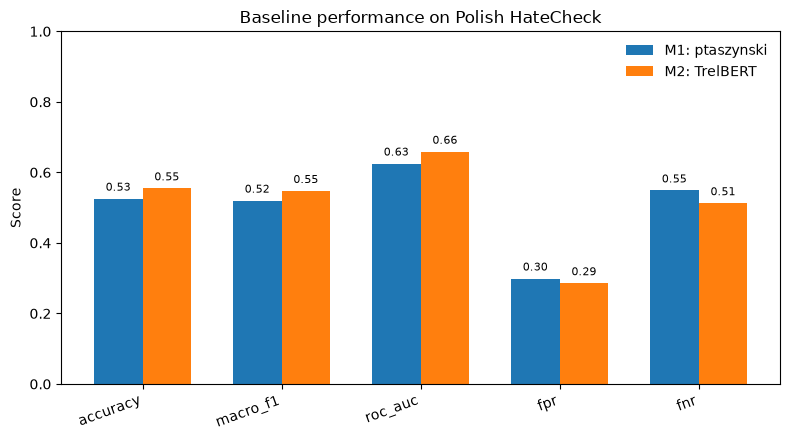

Saved: /Users/kacper/polish-hatespeech-audit/paper/figs/fig_baseline_m1_vs_m2_overall.pdf


In [22]:
plot_df = overall[["model", "accuracy", "macro_f1", "roc_auc", "fpr", "fnr"]].copy()
plot_long = plot_df.melt(id_vars="model", var_name="metric", value_name="value")

fig, ax = plt.subplots(figsize=(8, 4.5))

metrics = ["accuracy", "macro_f1", "roc_auc", "fpr", "fnr"]
x = np.arange(len(metrics))
width = 0.35

m1_vals = plot_df[plot_df["model"] == "M1: ptaszynski"][metrics].iloc[0].to_numpy()
m2_vals = plot_df[plot_df["model"] == "M2: TrelBERT"][metrics].iloc[0].to_numpy()

ax.bar(x - width / 2, m1_vals, width, label="M1: ptaszynski")
ax.bar(x + width / 2, m2_vals, width, label="M2: TrelBERT")

ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=20, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Baseline performance on Polish HateCheck")
ax.legend(frameon=False)

for i, v in enumerate(m1_vals):
    ax.text(i - width / 2, v + 0.015, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

for i, v in enumerate(m2_vals):
    ax.text(i + width / 2, v + 0.015, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

fig.tight_layout()

out = FIG_DIR / "fig_baseline_m1_vs_m2_overall.pdf"
fig.savefig(out)
plt.show()

print("Saved:", out)

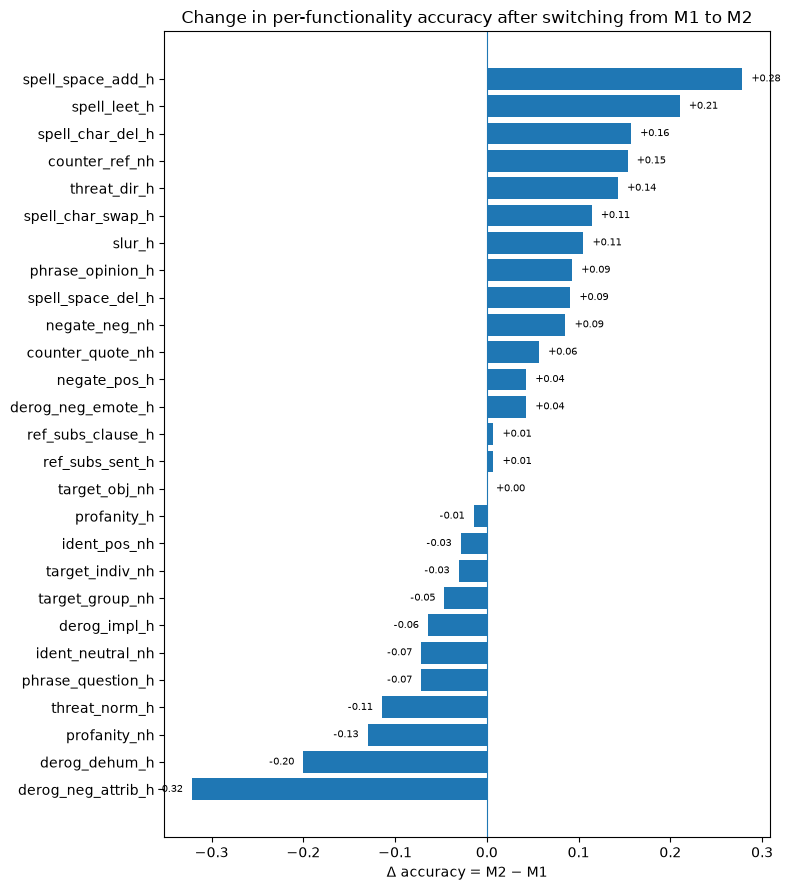

Saved: /Users/kacper/polish-hatespeech-audit/paper/figs/fig_m2_minus_m1_accuracy_per_functionality.pdf


In [21]:
plot_func = func_cmp.sort_values("delta_accuracy").copy()

fig, ax = plt.subplots(figsize=(8, 9))

y = np.arange(len(plot_func))
ax.barh(y, plot_func["delta_accuracy"])
ax.axvline(0, linewidth=0.8)

ax.set_yticks(y)
ax.set_yticklabels(plot_func["functionality"])
ax.set_xlabel("Δ accuracy = M2 − M1")
ax.set_title("Change in per-functionality accuracy after switching from M1 to M2")

for i, v in enumerate(plot_func["delta_accuracy"]):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f"{v:+.2f}", va="center", ha="left" if v >= 0 else "right", fontsize=7)

fig.tight_layout()

out = FIG_DIR / "fig_m2_minus_m1_accuracy_per_functionality.pdf"
fig.savefig(out)
plt.show()

print("Saved:", out)

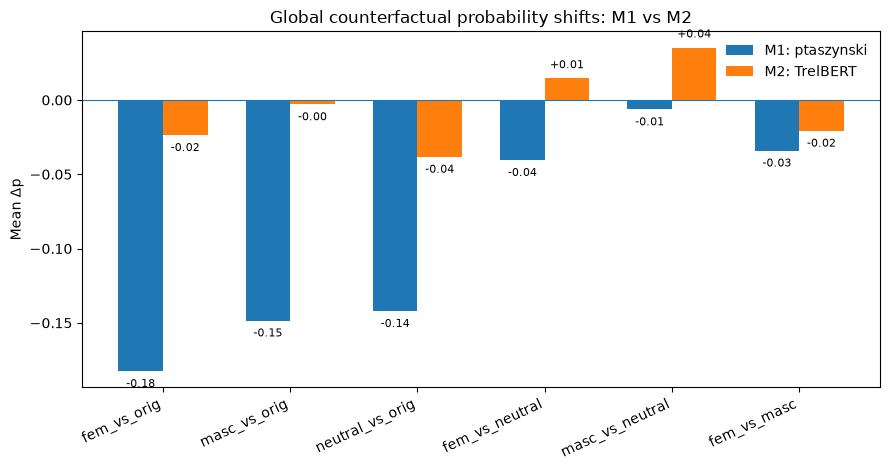

Saved: /Users/kacper/polish-hatespeech-audit/paper/figs/fig_cf_global_m1_vs_m2.pdf


In [23]:
plot_cf = cf_global_cmp.copy()
plot_cf["pair"] = pd.Categorical(plot_cf["pair"], categories=pair_order, ordered=True)
plot_cf = plot_cf.sort_values("pair")

x = np.arange(len(plot_cf))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4.8))

ax.bar(x - width / 2, plot_cf["m1_delta_mean"], width, label="M1: ptaszynski")
ax.bar(x + width / 2, plot_cf["m2_delta_mean"], width, label="M2: TrelBERT")

ax.axhline(0, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(plot_cf["pair"], rotation=25, ha="right")
ax.set_ylabel("Mean Δp")
ax.set_title("Global counterfactual probability shifts: M1 vs M2")
ax.legend(frameon=False)

for i, v in enumerate(plot_cf["m1_delta_mean"]):
    ax.text(i - width / 2, v + (0.005 if v >= 0 else -0.005), f"{v:+.2f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=8)

for i, v in enumerate(plot_cf["m2_delta_mean"]):
    ax.text(i + width / 2, v + (0.005 if v >= 0 else -0.005), f"{v:+.2f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=8)

fig.tight_layout()

out = FIG_DIR / "fig_cf_global_m1_vs_m2.pdf"
fig.savefig(out)
plt.show()

print("Saved:", out)

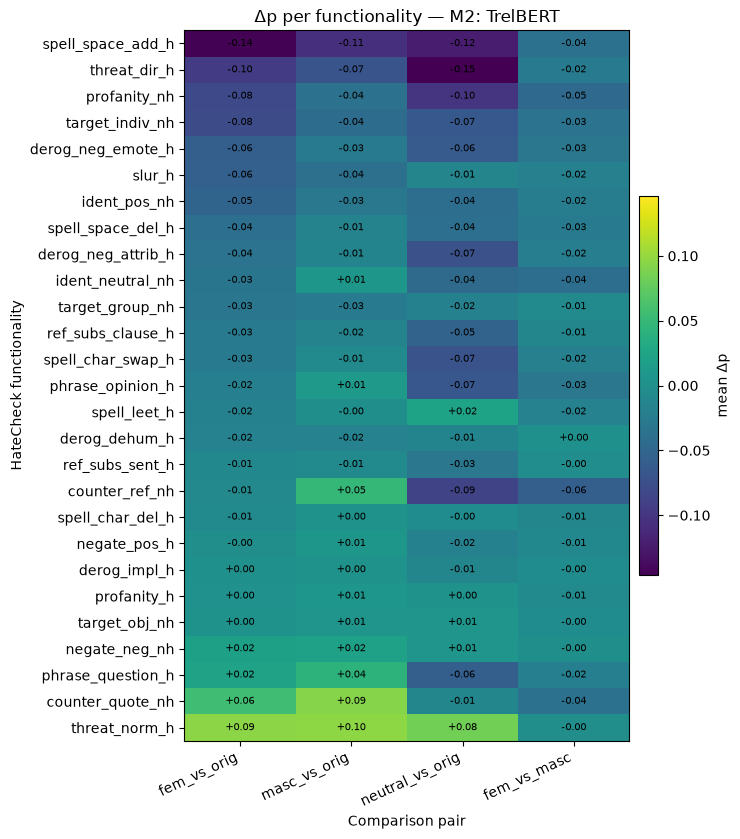

Saved: /Users/kacper/polish-hatespeech-audit/paper/figs/fig_trelbert_heatmap_per_functionality.pdf


In [24]:
pairs_for_heatmap = ["fem_vs_orig", "masc_vs_orig", "neutral_vs_orig", "fem_vs_masc"]

sub = m2_cf_stats[
    (m2_cf_stats["slice_type"] == "functionality") &
    (m2_cf_stats["pair"].isin(pairs_for_heatmap))
].copy()

pivot = sub.pivot(index="slice_value", columns="pair", values="delta_mean")
pivot = pivot[pairs_for_heatmap]
pivot = pivot.sort_values("fem_vs_orig")

fig, ax = plt.subplots(figsize=(7.5, 8.5))

vmax = float(np.nanmax(np.abs(pivot.to_numpy())))
im = ax.imshow(pivot.to_numpy(), aspect="auto", vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(pairs_for_heatmap)))
ax.set_xticklabels(pairs_for_heatmap, rotation=25, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:+.02f}", ha="center", va="center", fontsize=7)

cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("mean Δp")

ax.set_title("Δp per functionality — M2: TrelBERT")
ax.set_xlabel("Comparison pair")
ax.set_ylabel("HateCheck functionality")

fig.tight_layout()

out = FIG_DIR / "fig_trelbert_heatmap_per_functionality.pdf"
fig.savefig(out)
plt.show()

print("Saved:", out)

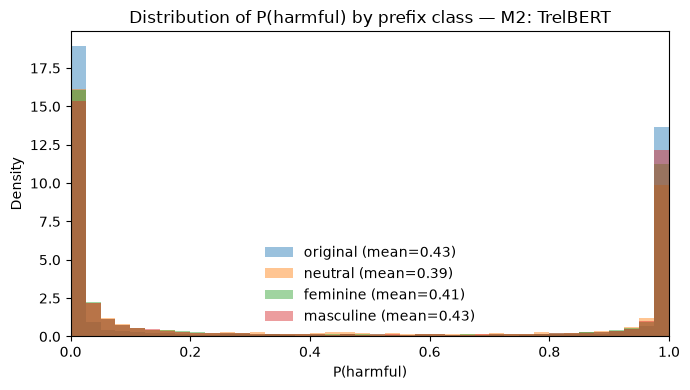

Saved: /Users/kacper/polish-hatespeech-audit/paper/figs/fig_trelbert_p_distribution.pdf


In [25]:
classes = ["original", "neutral", "feminine", "masculine"]

fig, ax = plt.subplots(figsize=(7, 4))

bins = np.linspace(0, 1, 41)

for cls in classes:
    s = m2_cf_pred.loc[m2_cf_pred["prefix_class"] == cls, "p_harmful"].to_numpy()
    ax.hist(
        s,
        bins=bins,
        alpha=0.45,
        label=f"{cls} (mean={s.mean():.2f})",
        density=True,
    )

ax.set_xlabel("P(harmful)")
ax.set_ylabel("Density")
ax.set_title("Distribution of P(harmful) by prefix class — M2: TrelBERT")
ax.legend(frameon=False)
ax.set_xlim(0, 1)

fig.tight_layout()

out = FIG_DIR / "fig_trelbert_p_distribution.pdf"
fig.savefig(out)
plt.show()

print("Saved:", out)

In [26]:
latex_dir = OUT_DIR / "latex_tables"
latex_dir.mkdir(parents=True, exist_ok=True)

# Overall table
overall_latex = overall_out.copy()
overall_latex["accuracy"] = overall_latex["accuracy"].map(lambda x: f"{x:.3f}")
overall_latex["macro_f1"] = overall_latex["macro_f1"].map(lambda x: f"{x:.3f}")
overall_latex["roc_auc"] = overall_latex["roc_auc"].map(lambda x: f"{x:.3f}")
overall_latex["fpr"] = overall_latex["fpr"].map(lambda x: f"{x:.3f}")
overall_latex["fnr"] = overall_latex["fnr"].map(lambda x: f"{x:.3f}")

overall_tex = overall_latex.to_latex(index=False, escape=True)
(latex_dir / "table_baseline_overall_m1_m2.tex").write_text(overall_tex, encoding="utf-8")

# M2 functionality worst/best
func_latex = m2_func_summary[["group", "functionality", "n", "accuracy", "fpr", "fnr"]].copy()
for c in ["accuracy", "fpr", "fnr"]:
    func_latex[c] = func_latex[c].map(lambda x: "—" if pd.isna(x) else f"{x:.3f}")

func_tex = func_latex.to_latex(index=False, escape=True)
(latex_dir / "table_m2_functionality_worst_best.tex").write_text(func_tex, encoding="utf-8")

# M2 global CF
cf_latex = m2_global[["pair", "delta_mean", "delta_ci_low", "delta_ci_high", "flip_rate", "wilcoxon_p_holm"]].copy()
for c in ["delta_mean", "delta_ci_low", "delta_ci_high", "flip_rate", "wilcoxon_p_holm"]:
    cf_latex[c] = cf_latex[c].map(lambda x: "—" if pd.isna(x) else f"{x:.4f}")

cf_tex = cf_latex.to_latex(index=False, escape=True)
(latex_dir / "table_m2_counterfactual_global.tex").write_text(cf_tex, encoding="utf-8")

print("Saved LaTeX tables to:", latex_dir)

for f in latex_dir.glob("*.tex"):
    print("\n---", f.name, "---")
    print(f.read_text(encoding="utf-8")[:1500])

Saved LaTeX tables to: /Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/latex_tables

--- table_baseline_overall_m1_m2.tex ---
\begin{tabular}{lrrrlllll}
\toprule
model & n & n\_pos & n\_neg & accuracy & macro\_f1 & roc\_auc & fpr & fnr \\
\midrule
M1: ptaszynski & 3815 & 2678 & 1137 & 0.526 & 0.520 & 0.625 & 0.299 & 0.549 \\
M2: TrelBERT & 3815 & 2678 & 1137 & 0.555 & 0.547 & 0.659 & 0.286 & 0.513 \\
\bottomrule
\end{tabular}


--- table_m2_functionality_worst_best.tex ---
\begin{tabular}{llrlll}
\toprule
group & functionality & n & accuracy & fpr & fnr \\
\midrule
Five worst & derog\_impl\_h & 140 & 0.279 & — & 0.721 \\
Five worst & derog\_neg\_emote\_h & 140 & 0.300 & — & 0.700 \\
Five worst & negate\_pos\_h & 140 & 0.307 & — & 0.693 \\
Five worst & phrase\_question\_h & 140 & 0.314 & — & 0.686 \\
Five worst & threat\_norm\_h & 140 & 0.393 & — & 0.607 \\
Three best & target\_obj\_nh & 65 & 0.923 & 0.077 & — \\
Three best & ident\_neutral\_nh & 140 & 0.893 & 0.

In [27]:
summary_text = f"""
M2 BASELINE SUMMARY

{paragraph}

M2 FUNCTIONALITY SUMMARY

{paragraph_func}

M2 COUNTERFACTUAL SUMMARY

{paragraph_cf}
""".strip()

print(summary_text)

with open(OUT_DIR / "m2_results_summary_for_paper.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print("\nSaved:", OUT_DIR / "m2_results_summary_for_paper.txt")

M2 BASELINE SUMMARY

On the full Polish HateCheck, M2 reaches accuracy 0.555, macro F1 0.547, and ROC-AUC 0.659.
Compared with M1, this is a change of +0.029 in accuracy, +0.027 in macro F1, and +0.034 in ROC-AUC.
The false-positive rate is 0.286, while the false-negative rate is 0.513.
Relative to M1, this changes FPR by -0.013 and FNR by -0.036.
This means that fine-tuning TrelBERT on the Polish cyberbullying corpus improves aggregate performance on the diagnostic HateCheck benchmark.

M2 FUNCTIONALITY SUMMARY

The per-functionality breakdown shows that M2's weakest categories are derog_impl_h (0.28), derog_neg_emote_h (0.30), negate_pos_h (0.31), phrase_question_h (0.31), threat_norm_h (0.39).
Its strongest categories are target_obj_nh (0.92), ident_neutral_nh (0.89), negate_neg_nh (0.87).
Compared with M1, the largest M2 gains are observed in spell_space_add_h (+0.28), spell_leet_h (+0.21), spell_char_del_h (+0.16), while the largest drops are observed in derog_neg_attrib_h (-0.32)

In [28]:
print("Generated analysis files:")
for p in sorted(OUT_DIR.rglob("*")):
    if p.is_file():
        print(p, round(p.stat().st_size / 1024, 1), "KB")

print("\nGenerated figures:")
for p in sorted(FIG_DIR.glob("*trelbert*.pdf")):
    print(p, round(p.stat().st_size / 1024, 1), "KB")

extra_figs = [
    FIG_DIR / "fig_baseline_m1_vs_m2_overall.pdf",
    FIG_DIR / "fig_m2_minus_m1_accuracy_per_functionality.pdf",
    FIG_DIR / "fig_cf_global_m1_vs_m2.pdf",
]

for p in extra_figs:
    if p.exists():
        print(p, round(p.stat().st_size / 1024, 1), "KB")

Generated analysis files:
/Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/baseline_overall_m1_m2.csv 0.3 KB
/Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/counterfactual_global_m1_m2_comparison.csv 1.7 KB
/Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/functionality_m1_m2_comparison.csv 5.2 KB
/Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/latex_tables/table_baseline_overall_m1_m2.tex 0.3 KB
/Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/latex_tables/table_m2_counterfactual_global.tex 0.5 KB
/Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/latex_tables/table_m2_functionality_worst_best.tex 0.6 KB
/Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/m2_counterfactual_global.csv 2.1 KB
/Users/kacper/polish-hatespeech-audit/paper/generated_trelbert_analysis/m2_fem_vs_masc_per_functionality.csv 7.7 KB
/Users/kacper/polish-hates